# 100 — Blast-chamber, radiator, and material envelope

This workbook connects the Phase-I reaction cards from Workbook 40 to a deliberately simple chamber and power-cycle model. It asks three separate questions:

1. How large must a chamber be to dilute one shot into a selected late-time gas-pressure rise?
2. How much wall is implied by pre-shot self-gravity and by pulse membrane strength?
3. If the chamber surface is also the radiator, what shot cadence, cycle-balanced power, and wall-material intensity follow?

This is a **preliminary envelope**, not blast hydrodynamics. The uniform-gas pressure is not the prompt shock at the first wall, and thin-shell gravity/strength equations become invalid when the inferred wall is not thin. Those failures are displayed rather than hidden.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

repo_root = Path.cwd()
while repo_root.name != 'CNO' and repo_root != repo_root.parent:
    repo_root = repo_root.parent
source_root = repo_root / 'analysis' / 'src'
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))

from cno_sweep import (
    BlastChamberAssumptions, RecipeShotCard, ThermalCycleAssumptions,
    asymptotic_balanced_fleet_specific_power_w_kg, balance_recipe_train,
    blast_chamber_envelope, roman_phase_one_target_sets,
    self_gravity_areal_density_kg_m2,
)
from cno_sweep.constants import ATOMIC_MASS

pd.set_option('display.max_columns', 40)
pd.set_option('display.precision', 5)
selected_sets, n15_costs = roman_phase_one_target_sets()
print('Loaded Workbook-40 target selections:', ', '.join(selected_sets))

Loaded Workbook-40 target selections: likely, conservative


## Exposed reference assumptions

The He chambers recover power; Constantine uses H2 for neutron-to-D breeding and, following the current conservative architecture, receives **no electrical credit**. Both still have to reject their deposited shot heat.

The 2,000 K value is the radiator/cold-reservoir temperature—not a claim that an ordinary metal turbine operates there. A 5,000 K hot reservoir, 70% of Carnot, and 10% electrical recirculation give 37.8% net export from He-chamber heat. Candidate hardware would have to be refractory/ceramic, MHD, or another high-temperature conversion system.

In [2]:
he_cycle = ThermalCycleAssumptions(
    hot_temperature_k=5000.0, cold_temperature_k=2000.0,
    carnot_utilization=0.70, exported_electric_fraction=0.90,
    radiator_emissivity=0.80,
)
h2_reject_only = ThermalCycleAssumptions(
    hot_temperature_k=5000.0, cold_temperature_k=2000.0,
    carnot_utilization=0.0, exported_electric_fraction=1.0,
    radiator_emissivity=0.80,
)

common = dict(
    pre_shot_pressure_pa=1.0e4,             # 0.1 bar
    permitted_pulse_pressure_pa=1.0e7,      # 100 bar late-time rise
    wall_density_kg_m3=3000.0,
    allowable_hot_stress_pa=3.0e8,          # 300 MPa screening value
    clearance_radius_factor=2.0,
    gas_temperature_k=2000.0,
)
he_assumptions = BlastChamberAssumptions(
    **common, gas_molar_mass_kg_mol=4.0026e-3, thermal_cycle=he_cycle
)
h2_assumptions = BlastChamberAssumptions(
    **common, gas_molar_mass_kg_mol=2.01588e-3, thermal_cycle=h2_reject_only
)

sigma_gravity_base = self_gravity_areal_density_kg_m2(common['pre_shot_pressure_pa'])
sigma_gravity_full_pulse = self_gravity_areal_density_kg_m2(
    common['pre_shot_pressure_pa'] + common['permitted_pulse_pressure_pa']
)
gravity_strength_crossover_m = (
    2 * common['allowable_hot_stress_pa'] * sigma_gravity_base
    / (common['wall_density_kg_m3'] * common['permitted_pulse_pressure_pa'])
)
pd.Series({
    'He Carnot limit': he_cycle.carnot_efficiency,
    'He gross electric efficiency': he_cycle.gross_electric_efficiency,
    'He net export efficiency': he_cycle.net_export_efficiency,
    '2000 K radiator flux (W/m2)': he_cycle.radiator_flux_w_m2,
    'base-pressure gravity areal mass (kg/m2)': sigma_gravity_base,
    'base gravity / pulse-strength crossover R (km)': gravity_strength_crossover_m / 1e3,
    'gravity areal mass if it alone held full pulse (kg/m2)': sigma_gravity_full_pulse,
}, name='reference').to_frame()

,reference
He Carnot limit,6.00000e-01
He gross electric efficiency,4.20000e-01
He net export efficiency,3.78000e-01
2000 K radiator flux (W/m2),7.25808e+05
base-pressure gravity areal mass (kg/m2),4.88323e+06
base gravity / pulse-strength crossover R (km),9.76646e+01
gravity areal mass if it alone held full pulse (kg/m2),1.54498e+08


## Governing zero-dimensional equations

For a thin spherical shell with areal density $\Sigma$, differentiation of its gravitational binding energy gives

$$P_g=2\pi G\Sigma^2,\qquad \Sigma_g=\sqrt{P_0/(2\pi G)}.$$

For a strength-supported thin spherical membrane,

$$t_s=\frac{\Delta P R}{2\sigma_{allow}},\qquad \Sigma_s=\rho_w t_s.$$

The first-pass wall inventory is $\max(\Sigma_g,\Sigma_s)$: structural material also counts as gravity ballast, so adding both would double-count. This does **not** prove that a practical layered wall can use all of that mass efficiently.

For a monatomic gas after complete mixing, $E=\Delta P V/(\gamma-1)$; therefore

$$R_{gas}=\left[\frac{3(\gamma-1)E}{4\pi\Delta P}\right]^{1/3}.$$

Finally, with the chamber exterior acting as the radiator,

$$t_{shot}=\frac{(1-\eta_e)E}{4\pi R^2\epsilon\sigma_{SB}(T_c^4-T_{space}^4)}.$$

In [3]:
rows = []
cards_by_case = {}
target_masses_by_case = {}
cno_masses_by_case = {}

for case_name, targets in selected_sets.items():
    cards = []
    target_mass_sum = 0.0
    cno_mass_sum = 0.0
    for recipe_id, target in targets.items():
        chamber_kind = 'H2 breeding' if recipe_id == 'constantine' else 'He recovery'
        assumptions = h2_assumptions if recipe_id == 'constantine' else he_assumptions
        chamber = blast_chamber_envelope(
            target.physical_target_outer_radius_m, target.total_fusion_yield_j, assumptions
        )
        cards.append(RecipeShotCard(
            target.radius_state.recipe.name, target.radius_state.successful_reactions,
            target.total_fusion_yield_j, chamber,
        ))
        target_mass_sum += target.total_target_mass_kg
        heavy_amu = {'caesar': 12, 'constantine': 13, 'aurelian': 16, 'scipio': 17, 'diocletian': 14}[recipe_id]
        cno_mass = (
            target.radius_state.initial_heavy_nuclei * heavy_amu * ATOMIC_MASS
            + target.loaded_n15_nuclei * 15.0 * ATOMIC_MASS
        )
        cno_mass_sum += cno_mass
        rows.append({
            'case': case_name, 'recipe': target.radius_state.recipe.name,
            'gas': chamber_kind, 'target R0 (m)': target.physical_target_outer_radius_m,
            'shot fusion yield (J)': target.total_fusion_yield_j,
            'chamber R (km)': chamber.chamber_radius_m / 1e3,
            'gas-buffer R (km)': chamber.gas_buffer_radius_m / 1e3,
            'wall basis': chamber.selected_wall_basis,
            'wall mass (kg)': chamber.wall_mass_kg,
            'gas mass (kg)': chamber.gas_mass_kg,
            'equiv wall t / R': chamber.selected_thickness_over_radius,
            'cooldown (days)': chamber.minimum_intershot_time_s / 86400,
            'max thermal W': chamber.maximum_thermal_power_w,
            'max exported electric W': chamber.maximum_exported_electric_power_w,
            'target mass (kg)': target.total_target_mass_kg,
            'CNO loaded (kg)': cno_mass,
            'successes / shot': target.radius_state.successful_reactions,
        })
    cards_by_case[case_name] = cards
    target_masses_by_case[case_name] = target_mass_sum
    cno_masses_by_case[case_name] = cno_mass_sum

chamber_table = pd.DataFrame(rows).set_index(['case', 'recipe'])
chamber_table

gas  target R0 (m)  shot fusion yield (J)  \
case         recipe                                                           
likely       Caesar       He recovery       34.31934            2.73983e+20   
             Constantine  H2 breeding       19.56375            8.97031e+19   
             Aurelian     He recovery       32.55995            1.74985e+20   
             Scipio       He recovery        2.57961            6.21765e+16   
             Diocletian   He recovery       32.96561            6.53023e+20   
conservative Caesar       He recovery      452.32455            1.66916e+24   
             Constantine  H2 breeding      207.52879            1.66070e+23   
             Aurelian     He recovery      409.64685            6.81521e+23   
             Scipio       He recovery       64.97321            2.51967e+21   
             Diocletian   He recovery      455.88707            2.47253e+24   

                          chamber R (km)  gas-buffer R (km)      wall basis  \
case         recipe                                                           
likely       Caesar             16.33733           16.33733    self-gravity   
             Constantine        11.26011           11.26011    self-gravity   
             Aurelian           14.06934           14.06934    self-gravity   
             Scipio              0.99651            0.99651    self-gravity   
             Diocletian         21.82309           21.82309    self-gravity   
conservative Caesar            298.38215          298.38215  pulse strength   
             Constantine       138.26240          138.26240  pulse strength   
             Aurelian          221.36033          221.36033  pulse strength   
             Scipio             34.22851           34.22851    self-gravity   
             Diocletian        340.13695          340.13695  pulse strength   

                          wall mass (kg)  gas mass (kg)  equiv wall t / R  \
case         recipe                                                         
likely       Caesar          1.63787e+16    4.39653e+10           0.09963   
             Constantine     7.78040e+15    7.24965e+09           0.14456   
             Aurelian        1.21469e+16    2.80794e+10           0.11569   
             Scipio          6.09370e+13    9.97729e+06           1.63344   
             Diocletian      2.92247e+16    1.04789e+11           0.07459   
conservative Caesar          1.66916e+19    2.67846e+14           0.01667   
             Constantine     1.66070e+18    1.34215e+13           0.01667   
             Aurelian        6.81521e+18    1.09362e+14           0.01667   
             Scipio          7.18941e+16    4.04325e+11           0.04756   
             Diocletian      2.47253e+19    3.96760e+14           0.01667   

                          cooldown (days)  max thermal W  \
case         recipe                                        
likely       Caesar               0.81023    3.91384e+15   
             Constantine          0.89779    1.15642e+15   
             Aurelian             0.69775    2.90261e+15   
             Scipio               0.04942    1.45615e+13   
             Diocletian           1.08228    6.98351e+15   
conservative Caesar              14.79782    1.30553e+18   
             Constantine         11.02399    1.74357e+17   
             Aurelian            10.97804    7.18523e+17   
             Scipio               1.69751    1.71798e+16   
             Diocletian          16.86859    1.69648e+18   

                          max exported electric W  target mass (kg)  \
case         recipe                                                   
likely       Caesar                   1.47943e+15       5.06243e+07   
             Constantine              0.00000e+00       1.47631e+07   
             Aurelian                 1.09719e+15       7.09849e+07   
             Scipio                   5.50424e+12       2.23619e+04   
             Diocletian               2.63977e+15       9.57293e

### Interpretation checkpoint

`equiv wall t / R` is also a model-validity warning. Values that are not much less than one mean the thin-shell result is only an areal-mass flag, not a believable geometry. Prompt wall impulse, ablation, cracking, liquid/sacrificial liners, beam ports, gas shocks, neutron damage, and heat transport through kilometres of material are not yet modeled.

In [4]:
# Thermal-diffusion alarm, not a selected wall material property.
reference_diffusivity_m2_s = 1.0e-6
diffusion_alarm = chamber_table[['equiv wall t / R', 'chamber R (km)']].copy()
diffusion_alarm['equiv wall thickness (m)'] = (
    diffusion_alarm['equiv wall t / R'] * diffusion_alarm['chamber R (km)'] * 1e3
)
diffusion_alarm['solid diffusion time (years)'] = (
    diffusion_alarm['equiv wall thickness (m)'] ** 2
    / reference_diffusivity_m2_s / (365.25 * 86400)
)
diffusion_alarm

equiv wall t / R  chamber R (km)  \
case         recipe                                          
likely       Caesar                0.09963        16.33733   
             Constantine           0.14456        11.26011   
             Aurelian              0.11569        14.06934   
             Scipio                1.63344         0.99651   
             Diocletian            0.07459        21.82309   
conservative Caesar                0.01667       298.38215   
             Constantine           0.01667       138.26240   
             Aurelian              0.01667       221.36033   
             Scipio                0.04756        34.22851   
             Diocletian            0.01667       340.13695   

                          equiv wall thickness (m)  \
case         recipe                                  
likely       Caesar                     1627.74342   
             Constantine                1627.74342   
             Aurelian                   1627.74342   
             Scipio                     1627.74342   
             Diocletian                 1627.74342   
conservative Caesar                     4973.03580   
             Constantine                2304.37336   
             Aurelian                   3689.33876   
             Scipio                     1627.74342   
             Diocletian                 5668.94910   

                          solid diffusion time (years)  
case         recipe                                     
likely       Caesar                        8.39591e+04  
             Constantine                   8.39591e+04  
             Aurelian                      8.39591e+04  
             Scipio                        8.39591e+04  
             Diocletian                    8.39591e+04  
conservative Caesar                        7.83681e+05  
             Constantine                   1.68268e+05  
             Aurelian                      4.31314e+05  
             Scipio                        8.39591e+04  
             Diocletian                    1.01836e+06

In [5]:
train_rows = []
trains = {}
for case_name, cards in cards_by_case.items():
    train = balance_recipe_train(
        cards, target_mass_in_one_loaded_set_kg=target_masses_by_case[case_name]
    )
    trains[case_name] = train
    specific = asymptotic_balanced_fleet_specific_power_w_kg(cards)
    train_rows.append({
        'case': case_name, 'one-each limiting recipe': train.limiting_recipe,
        'traversals / s': train.traversal_rate_s,
        'balanced thermal W': train.thermal_power_w,
        'balanced exported electric W': train.exported_electric_power_w,
        'effective net efficiency': train.exported_electric_power_w / train.thermal_power_w,
        'five-chamber wall mass (kg)': train.total_wall_mass_kg,
        'one loaded target set (kg)': target_masses_by_case[case_name],
        'wall / one target set': train.total_wall_mass_kg / target_masses_by_case[case_name],
        'wall / one CNO loading': train.total_wall_mass_kg / cno_masses_by_case[case_name],
        'scaled balanced fleet electric W/kg wall': specific,
    })
train_table = pd.DataFrame(train_rows).set_index('case')
train_table

,one-each limiting recipe,traversals / s,balanced thermal W,balanced exported electric W,effective net efficiency,five-chamber wall mass (kg),one loaded target set (kg),wall / one target set,wall / one CNO loading,scaled balanced fleet electric W/kg wall
case,,,,,,,,,,
likely,Scipio,6.96370e+25,2.20463e+14,7.36255e+13,0.33396,6.55916e+16,2.32124e+08,2.82571e+08,6.39413e+08,0.07453
conservative,Scipio,8.12095e+28,2.64455e+17,8.85903e+16,0.33499,4.99647e+19,8.27963e+11,6.03466e+07,1.64766e+08,0.02758


A five-chamber train cannot be evaluated by adding all five chambers at their individual maximum rates. Every catalyst traversal needs one success in every recipe. The table therefore throttles each chamber to the same successful-reaction throughput. A mature fleet can instead replicate recipe chambers in the required proportions; the final column is that asymptotic electrical power per kilogram of wall.

In [6]:
rate_rows = []
inventory_rows = []
for case_name, cards in cards_by_case.items():
    train = trains[case_name]
    total_target_flow = 0.0
    for card in cards:
        rate = train.shot_rates_hz[card.recipe]
        target = next(t for t in selected_sets[case_name].values() if t.radius_state.recipe.name == card.recipe)
        flow = target.total_target_mass_kg * rate
        total_target_flow += flow
        rate_rows.append({
            'case': case_name, 'recipe': card.recipe,
            'balanced shots/day': rate * 86400,
            'target fabrication flow (kg/s)': flow,
        })
    equal_residence = train.total_wall_mass_kg / total_target_flow
    for residence_days in (1, 30, 365, 3650):
        inventory_rows.append({
            'case': case_name, 'preprocessing residence (days)': residence_days,
            'target-stream inventory (kg)': total_target_flow * residence_days * 86400,
            'inventory / wall': total_target_flow * residence_days * 86400 / train.total_wall_mass_kg,
            'residence equaling wall inventory (years)': equal_residence / (365.25 * 86400),
        })
display(pd.DataFrame(rate_rows).set_index(['case', 'recipe']))
pd.DataFrame(inventory_rows).set_index(['case', 'preprocessing residence (days)'])

balanced shots/day  target fabrication flow (kg/s)
case         recipe                                                         
likely       Caesar                  0.00763                         4.47093
             Constantine             0.02474                         4.22748
             Aurelian                0.01276                        10.48091
             Scipio                 20.23453                         5.23706
             Diocletian              0.01722                        19.08382
conservative Caesar                  0.00142                      3182.56212
             Constantine             0.01565                      3356.55568
             Aurelian                0.00654                     20065.03929
             Scipio                  0.58910                      3853.93540
             Diocletian              0.00483                     19552.12470

target-stream inventory (kg)  \
case         preprocessing residence (days)                                 
likely       1                                                3.75842e+06   
             30                                               1.12753e+08   
             365                                              1.37182e+09   
             3650                                             1.37182e+10   
conservative 1                                                4.32088e+09   
             30                                               1.29626e+11   
             365                                              1.57712e+12   
             3650                                             1.57712e+13   

                                             inventory / wall  \
case         preprocessing residence (days)                     
likely       1                                    5.73003e-11   
             30                                   1.71901e-09   
             365                                  2.09146e-08   
             3650                                 2.09146e-07   
conservative 1                                    8.64787e-11   
             30                                   2.59436e-09   
             365                                  3.15647e-08   
             3650                                 3.15647e-07   

                                             residence equaling wall inventory (years)  
case         preprocessing residence (days)                                             
likely       1                                                             4.77807e+07  
             30                                                            4.77807e+07  
             365                                                           4.77807e+07  
             3650                                                          4.77807e+07  
conservative 1                                                             3.16593e+07  
             30                                                            3.16593e+07  
             365                                                           3.16593e+07  
             3650                                                          3.16593e+07

## The CNO inventory as a circular river

The idea is sound for the stable isotopes on the selected mainline: C12, C13, O16, O17, N14, and N15 can enter at their corresponding station and eventually circulate. It changes bootstrap timing, not the steady one-in/one-out topology. Important holes/qualifications are:

- It is not true for arbitrary C/N/O isotopes. Off-mainline isotopes can require extra reactions, decay away, or poison a recipe.
- Entry at N14 must cross slow Diocletian before producing N15. Entry at N15 can immediately supply Trajan and return C12, so entry point controls the startup transient.
- Exactly one N15 must be produced and one N15 burned per completed catalyst traversal. Recovery loss requires continuing makeup feed.
- Constantine needs an alpha before the loop has produced its steady alpha surplus. D fusion can bootstrap both alpha inventory and a DT-rich substitute pusher.
- A natural-D bridge is finite startup capital. Tritium still has to be bred, and its D/T ledger cannot be credited as steady closure.
- A claimed D surplus exists only after Constantine neutrons escape the target, become D in H, cool, survive further reactions, and are recovered.

Thus the right bootstrap model is a time-dependent inventory fill problem. The circular-river picture is a good conceptual description once those entry delays and losses are explicit.

## Solar-System material ceiling

The next table deliberately treats each listed body mass as a **100%-usable upper bound**, then exposes a usable refractory fraction. Planet masses come from [NASA's planetary fact sheets](https://nssdc.gsfc.nasa.gov/planetary/factsheet/). Bulk Uranus/Neptune are not ready-made wall material: volatile ices and H/He at 2,000 K cannot simply serve as an uncontained hot structural shell. Venus, Mercury, Mars, the Moon, asteroids, and rocky cores are materially more plausible, although extraction dominates any real design.

In [7]:
body_masses = {
    'Moon': 7.342e22, 'Mercury': 3.3011e23, 'Mars': 6.4171e23,
    'Venus': 4.8675e24, 'Earth': 5.9722e24,
    'inner rocky subtotal': 7.342e22 + 3.3011e23 + 6.4171e23 + 4.8675e24 + 5.9722e24,
    'Uranus whole-body upper bound': 8.681e25,
    'Neptune whole-body upper bound': 1.024e26,
}
usable_fractions = (0.01, 0.10, 1.00)
scale_rows = []
for case_name, cards in cards_by_case.items():
    specific = asymptotic_balanced_fleet_specific_power_w_kg(cards)
    for body, mass in body_masses.items():
        for fraction in usable_fractions:
            scale_rows.append({
                'case': case_name, 'source mass scenario': body,
                'usable fraction': fraction, 'usable wall mass (kg)': mass * fraction,
                'exported electric ceiling (W)': mass * fraction * specific,
                'fraction of solar luminosity': mass * fraction * specific / 3.828e26,
            })
material_ceiling = pd.DataFrame(scale_rows).set_index(['case', 'source mass scenario', 'usable fraction'])
material_ceiling

usable wall mass (kg)  \
case         source mass scenario           usable fraction                          
likely       Moon                           0.01                       7.34200e+20   
                                            0.10                       7.34200e+21   
                                            1.00                       7.34200e+22   
             Mercury                        0.01                       3.30110e+21   
                                            0.10                       3.30110e+22   
                                            1.00                       3.30110e+23   
             Mars                           0.01                       6.41710e+21   
                                            0.10                       6.41710e+22   
                                            1.00                       6.41710e+23   
             Venus                          0.01                       4.86750e+22   
                                            0.10                       4.86750e+23   
                                            1.00                       4.86750e+24   
             Earth                          0.01                       5.97220e+22   
                                            0.10                       5.97220e+23   
                                            1.00                       5.97220e+24   
             inner rocky subtotal           0.01                       1.18849e+23   
                                            0.10                       1.18849e+24   
                                            1.00                       1.18849e+25   
             Uranus whole-body upper bound  0.01                       8.68100e+23   
                                            0.10                       8.68100e+24   
                                            1.00                       8.68100e+25   
             Neptune whole-body upper bound 0.01                       1.02400e+24   
                                            0.10                       1.02400e+25   
                                            1.00                       1.02400e+26   
conservative Moon                           0.01                       7.34200e+20   
                                            0.10                       7.34200e+21   
                                            1.00                       7.34200e+22   
             Mercury                        0.01                       3.30110e+21   
                                            0.10                       3.30110e+22   
                                            1.00                       3.30110e+23   
             Mars                           0.01                       6.41710e+21   
                                            0.10                       6.41710e+22   
                                            1.00                       6.41710e+23   
             Venus                          0.01                       4.86750e+22   
                                            0.10                       4.86750e+23   
                                            1.00                       4.86750e+24   
             Earth                          0.01                       5.97220e+22   
                                            0.10                       5.97220e+23   
                                            1.00                       5.97220e+24   
             inner rocky subtotal           0.01                       1.18849e+23   
                                            0.10                       1.18849e+24   
                                            1.00                       1.18849e+25   
             Uranus whole-body upper bound  0.01                       8.68100e+23   
                                            0.10                       8.68100e+24   
                                            1.00                       8.68100e+25   
             Neptun

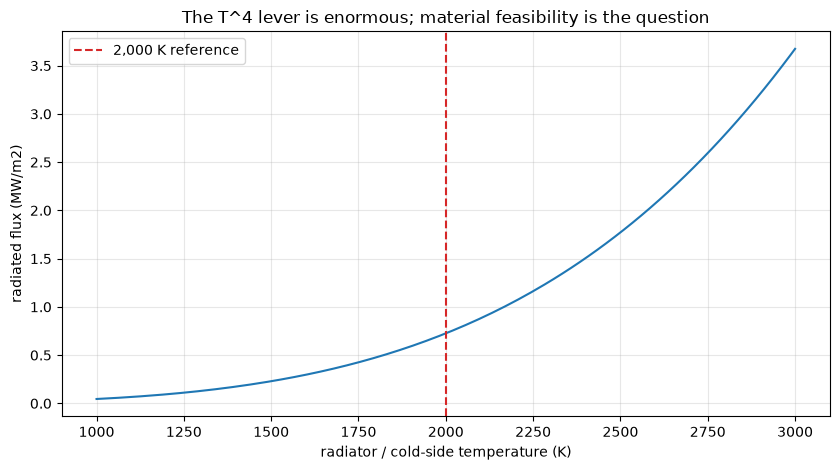

In [8]:
temperatures = np.linspace(1000.0, 3000.0, 160)
fluxes = 0.8 * 5.670374419e-8 * (temperatures**4 - 3.0**4)
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(temperatures, fluxes / 1e6)
ax.axvline(2000.0, color='tab:red', linestyle='--', label='2,000 K reference')
ax.set(xlabel='radiator / cold-side temperature (K)', ylabel='radiated flux (MW/m2)',
       title='The T^4 lever is enormous; material feasibility is the question')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()

## Preliminary conclusions and next audit gates

1. At 2,000 K the radiator is compact in area but extreme in materials. There is no thermodynamic show-stopper if the hot reservoir is much hotter; there is a major unresolved machinery, heat-exchanger, and wall-lifetime problem.
2. In this gravity-balloon reference, chamber wall mass exceeds one loaded target set by many orders of magnitude. The preprocessing inventory only catches up after the displayed residence time; this supports—but does not yet prove—the hypothesis that walls dominate CNO inventory.
3. Self-gravity is not automatically mass-efficient. At 0.1 bar it requires about $4.88\times10^6$ kg/m2, equivalent to 1.63 km of 3,000 kg/m3 material. It becomes competitive with pulse membrane strength only beyond a parameter-dependent crossover radius.
4. Scipio sets the one-of-each chamber train's catalyst throughput in both Phase-I brackets because its target contains far fewer successful central reactions per shot. A scaled plant must replicate chamber recipes in unequal numbers.
5. A Solar-System-wide power ceiling is therefore not one number yet. It is the usable refractory/structural fraction times the balanced fleet W/kg, and it changes as $T_{radiator}^4$, $P_0^{-1/2}$ in the gravity regime, and with allowable hot stress in the strength regime.

Before this becomes a reference chamber, the next calculation must replace uniform late-time pressure with prompt impulse/fluence limits; choose a thick-shell, rubble-ballast, liquid-wall, or suspended pressure-vessel geometry; and account for heat conduction from the inner surface to the radiating surface.